In [3]:
!pip3 install seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 4.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 5.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 5.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [seaborn]m7/8 [seaborn]ib]

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: /Library/Frameworks/Python.framework/Versions/3.13/bin/python3.13 -m pip install --upgrade pip


In [4]:
import pandas as pd       
import seaborn as sns     
import matplotlib.pyplot as plt  


Matplotlib is building the font cache; this may take a moment.


In [5]:

df = pd.read_csv("airports.csv")

# Check how many missing values are in each column
missing_values = df.isnull().sum()
print(" Missing values per column:\n")
print(missing_values)

#  Show only rows that contain at least one missing value
rows_with_missing = df[df.isnull().any(axis=1)]
print("\n Rows with missing data:\n")
print(rows_with_missing)


🔍 Missing values per column:

IATA_CODE    0
AIRPORT      0
CITY         0
STATE        0
COUNTRY      0
LATITUDE     3
LONGITUDE    3
dtype: int64

 Rows with missing data:

    IATA_CODE                                            AIRPORT  \
96        ECP    Northwest Florida Beaches International Airport   
234       PBG                  Plattsburgh International Airport   
313       UST  Northeast Florida Regional Airport (St. August...   

              CITY STATE COUNTRY  LATITUDE  LONGITUDE  
96     Panama City    FL     USA       NaN        NaN  
234    Plattsburgh    NY     USA       NaN        NaN  
313  St. Augustine    FL     USA       NaN        NaN  


In [ ]:

df = pd.read_csv("flights.csv", low_memory=False)

# Check how many missing values are in each column
missing_values = df.isnull().sum()
print(" Missing values per column:\n")
print(missing_values)

#  Show only rows that contain at least one missing value
rows_with_missing = df[df.isnull().any(axis=1)]
print("\n Rows with missing data:\n")
print(rows_with_missing)


 Missing values per column:

YEAR                         0
MONTH                        0
DAY                          0
DAY_OF_WEEK                  0
AIRLINE                      0
FLIGHT_NUMBER                0
TAIL_NUMBER              14721
ORIGIN_AIRPORT               0
DESTINATION_AIRPORT          0
SCHEDULED_DEPARTURE          0
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
TAXI_OUT                 89047
WHEELS_OFF               89047
SCHEDULED_TIME               6
ELAPSED_TIME            105071
AIR_TIME                105071
DISTANCE                     0
WHEELS_ON                92513
TAXI_IN                  92513
SCHEDULED_ARRIVAL            0
ARRIVAL_TIME             92513
ARRIVAL_DELAY           105071
DIVERTED                     0
CANCELLED                    0
CANCELLATION_REASON    5729195
AIR_SYSTEM_DELAY       4755640
SECURITY_DELAY         4755640
AIRLINE_DELAY          4755640
LATE_AIRCRAFT_DELAY    4755640
WEATHER_DELAY          4755640
dtype: int

 Showing heatmap for features most correlated with ARRIVAL_DELAY...


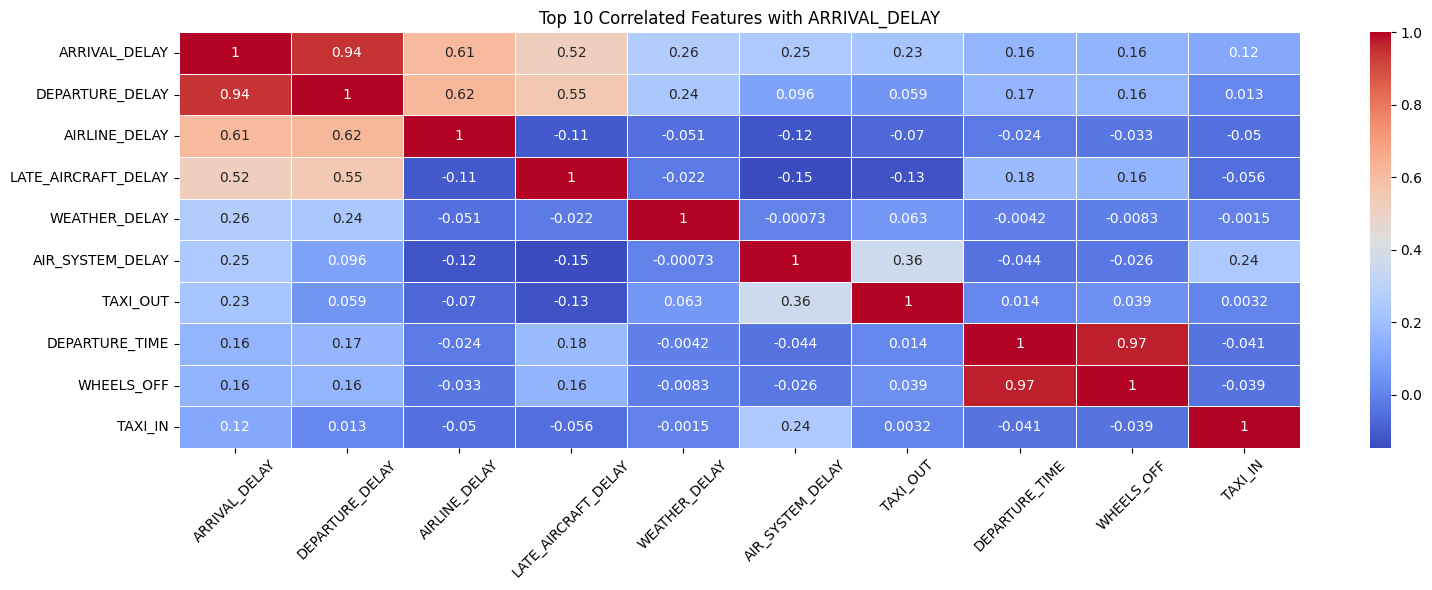

In [16]:

import numpy as np




df = pd.read_csv("flights.csv", low_memory=False)

# Convert everything to numeric — text becomes NaN
df = df.apply(pd.to_numeric, errors='coerce')

# Drop columns that are completely empty (all NaN)
df = df.dropna(axis=1, how='all')

# Drop rows that still have too many missing values (keep ones with at least 5 real values)
df = df.dropna(thresh=5)

# Check if 'ARRIVAL_DELAY' exists
if 'ARRIVAL_DELAY' not in df.columns:
    raise ValueError("'ARRIVAL_DELAY' column not found in your data.")

# Create the correlation matrix
corr_matrix = df.corr()

# Pick top 10 most correlated features with arrival delay
k = 10
top_features = corr_matrix['ARRIVAL_DELAY'].abs().nlargest(k).index
top_corr_matrix = df[top_features].corr()

# Only draw the heatmap if there's actual data
if top_corr_matrix.isnull().all().all() or top_corr_matrix.empty:
    print(" No usable data for heatmap. The selected columns are still all empty.")
    print(" Here's what the matrix looks like:")
    print(top_corr_matrix)
else:
    print(" Showing heatmap for features most correlated with ARRIVAL_DELAY...")
    plt.figure(figsize=(16, 6))
    sns.heatmap(top_corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
    plt.title(f"Top {k} Correlated Features with ARRIVAL_DELAY")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


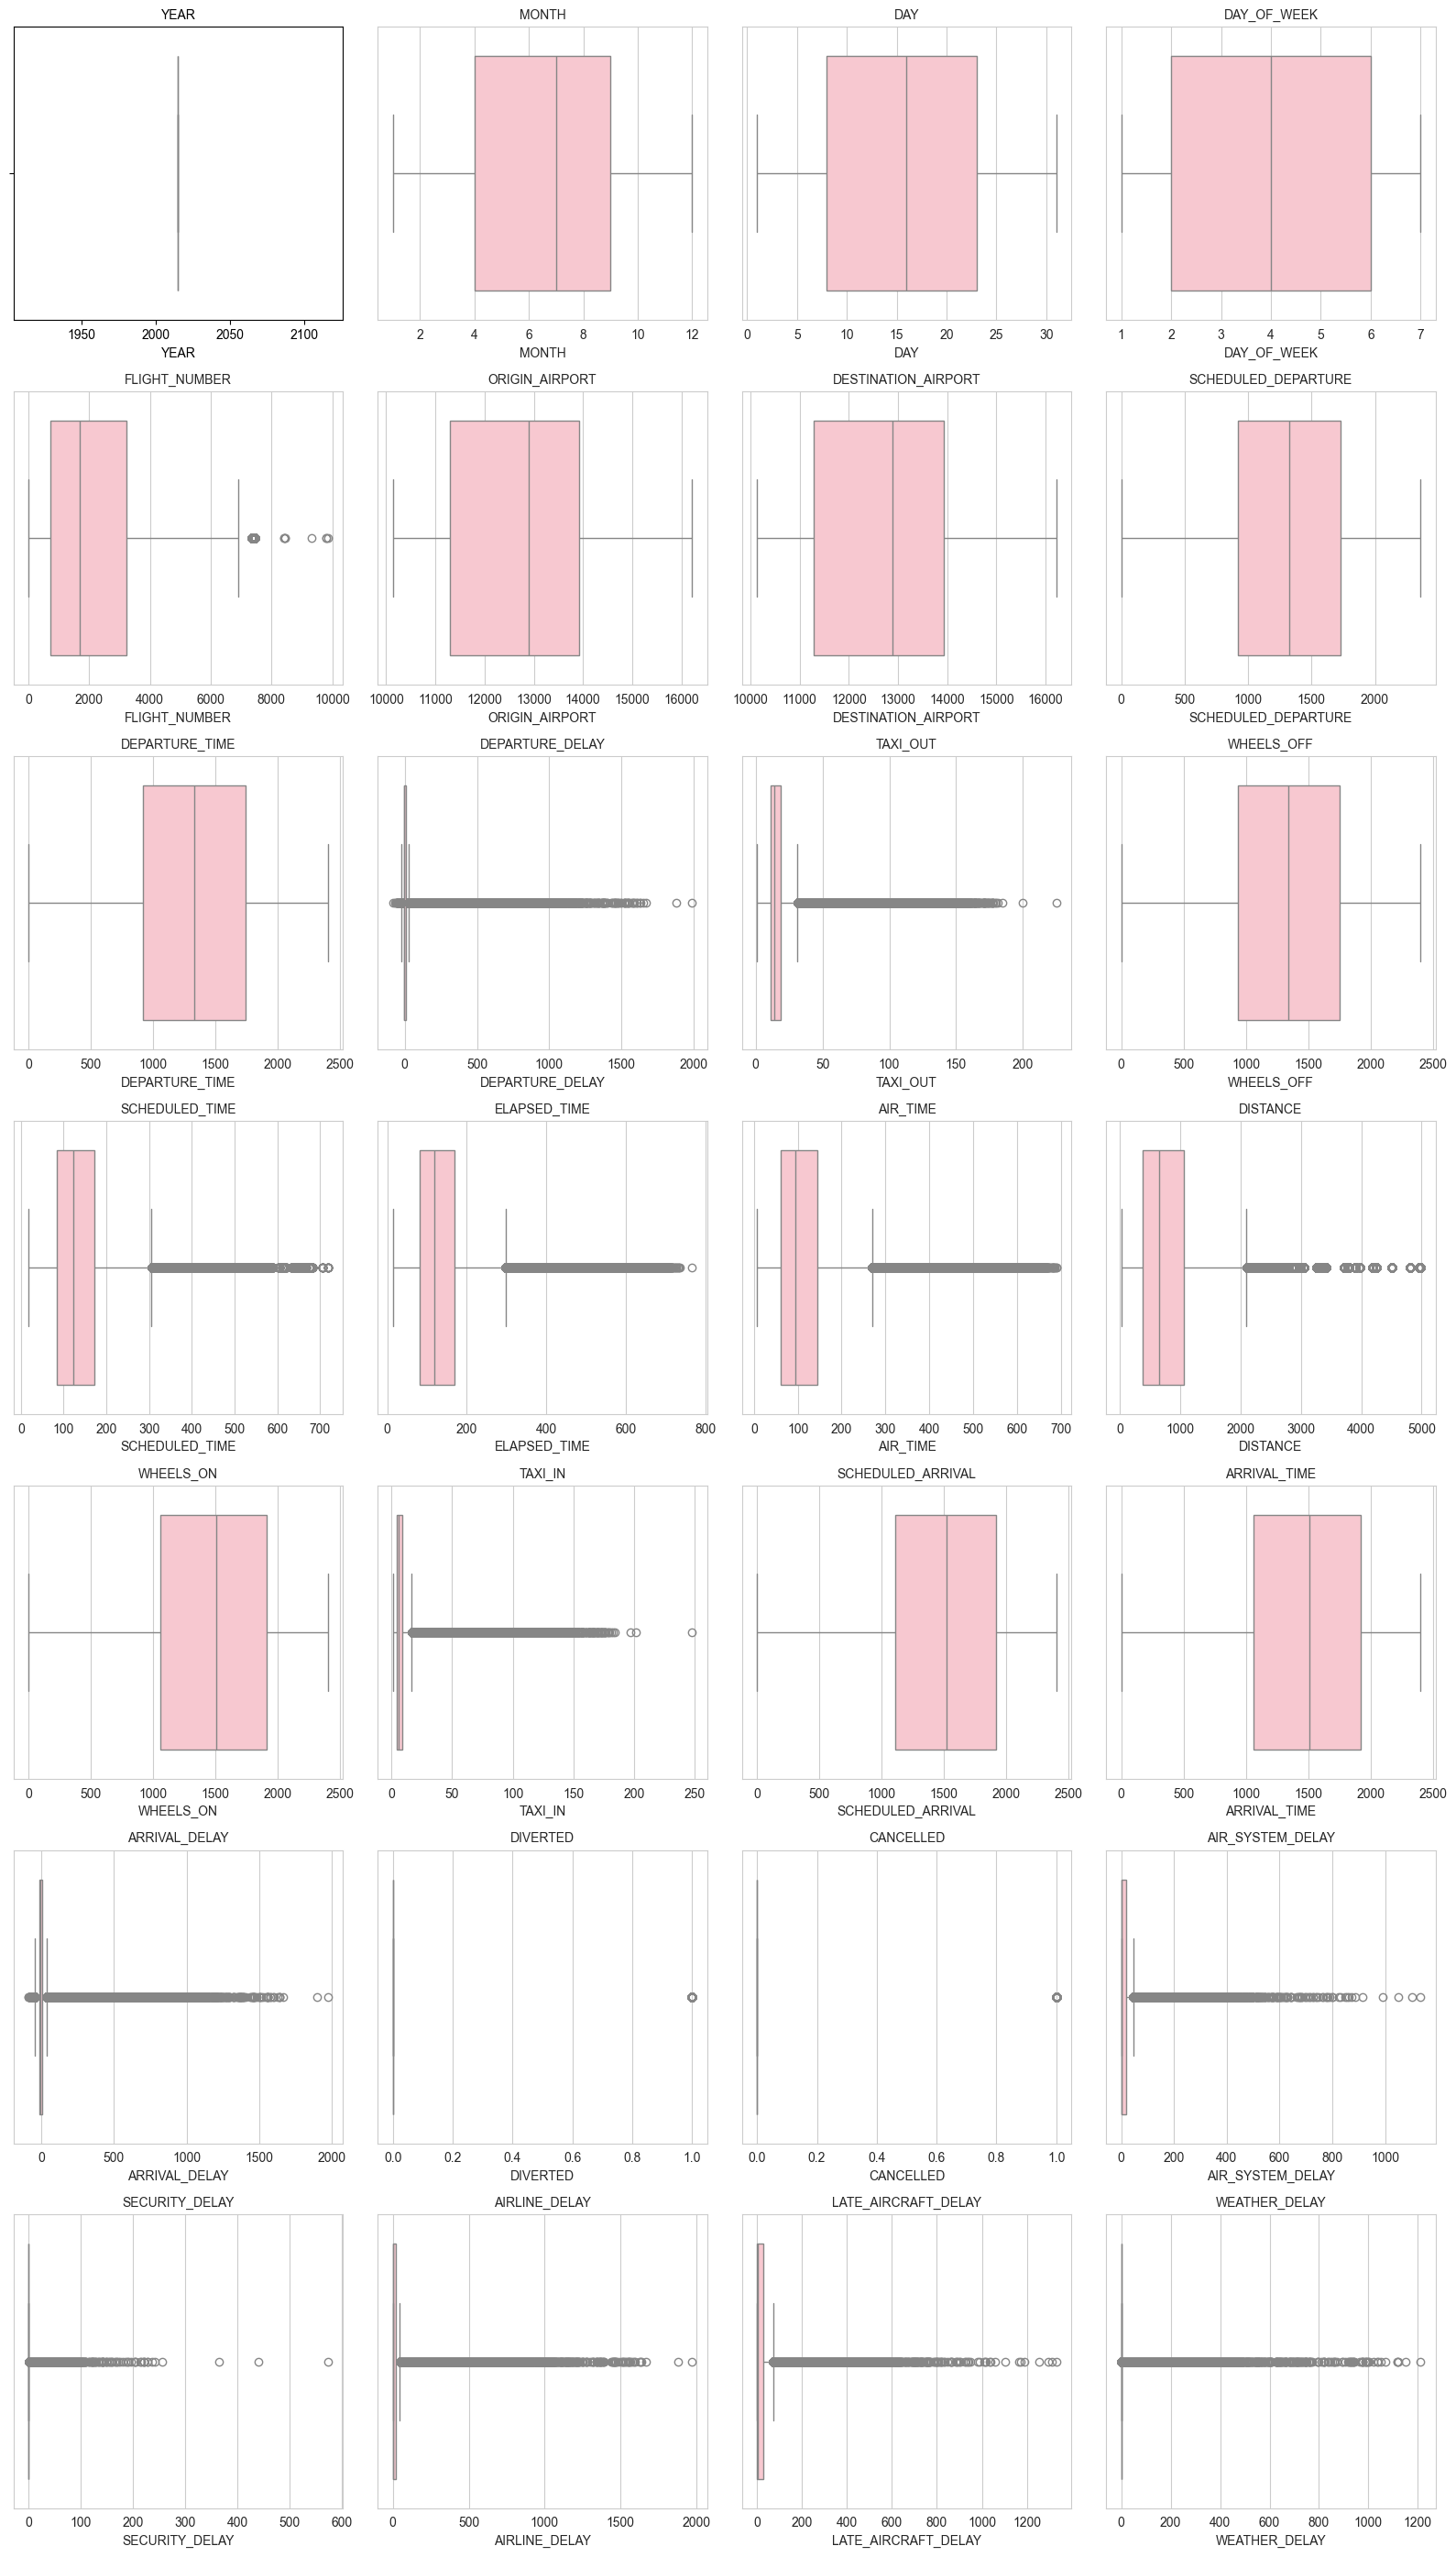

In [18]:

import math


df = pd.read_csv("flights.csv", low_memory=False)

#  Convert all columns to numeric (non-numeric become NaN)
df = df.apply(pd.to_numeric, errors='coerce')

#  Drop columns with all missing values
df = df.dropna(axis=1, how='all')

#  Drop rows with fewer than 5 valid values
df = df.dropna(thresh=5)

#  Get all numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns

#  Set up a grid for multiple plots
number_of_columns = 4
number_of_plots = len(numeric_cols)
number_of_rows = math.ceil(number_of_plots / number_of_columns)

plt.figure(figsize=(number_of_columns * 4, number_of_rows * 4))

#  Create a boxplot for each numeric column
for i in range(number_of_plots):
    plt.subplot(number_of_rows, number_of_columns, i + 1)
    sns.set_style('whitegrid')
    sns.boxplot(x=df[numeric_cols[i]], color='pink')
    plt.title(numeric_cols[i], fontsize=10)

plt.tight_layout()
plt.show()

Plotting: YEAR
Plotting: MONTH
Plotting: DAY
Plotting: DAY_OF_WEEK
Plotting: FLIGHT_NUMBER
Plotting: ORIGIN_AIRPORT
Plotting: DESTINATION_AIRPORT
Plotting: SCHEDULED_DEPARTURE
Plotting: DEPARTURE_TIME
Plotting: DEPARTURE_DELAY
Plotting: TAXI_OUT
Plotting: WHEELS_OFF
Plotting: SCHEDULED_TIME
Plotting: ELAPSED_TIME
Plotting: AIR_TIME
Plotting: DISTANCE
Plotting: WHEELS_ON
Plotting: TAXI_IN
Plotting: SCHEDULED_ARRIVAL
Plotting: ARRIVAL_TIME
Plotting: ARRIVAL_DELAY
Plotting: DIVERTED
Plotting: CANCELLED
Plotting: AIR_SYSTEM_DELAY
Plotting: SECURITY_DELAY
Plotting: AIRLINE_DELAY
Plotting: LATE_AIRCRAFT_DELAY
Plotting: WEATHER_DELAY


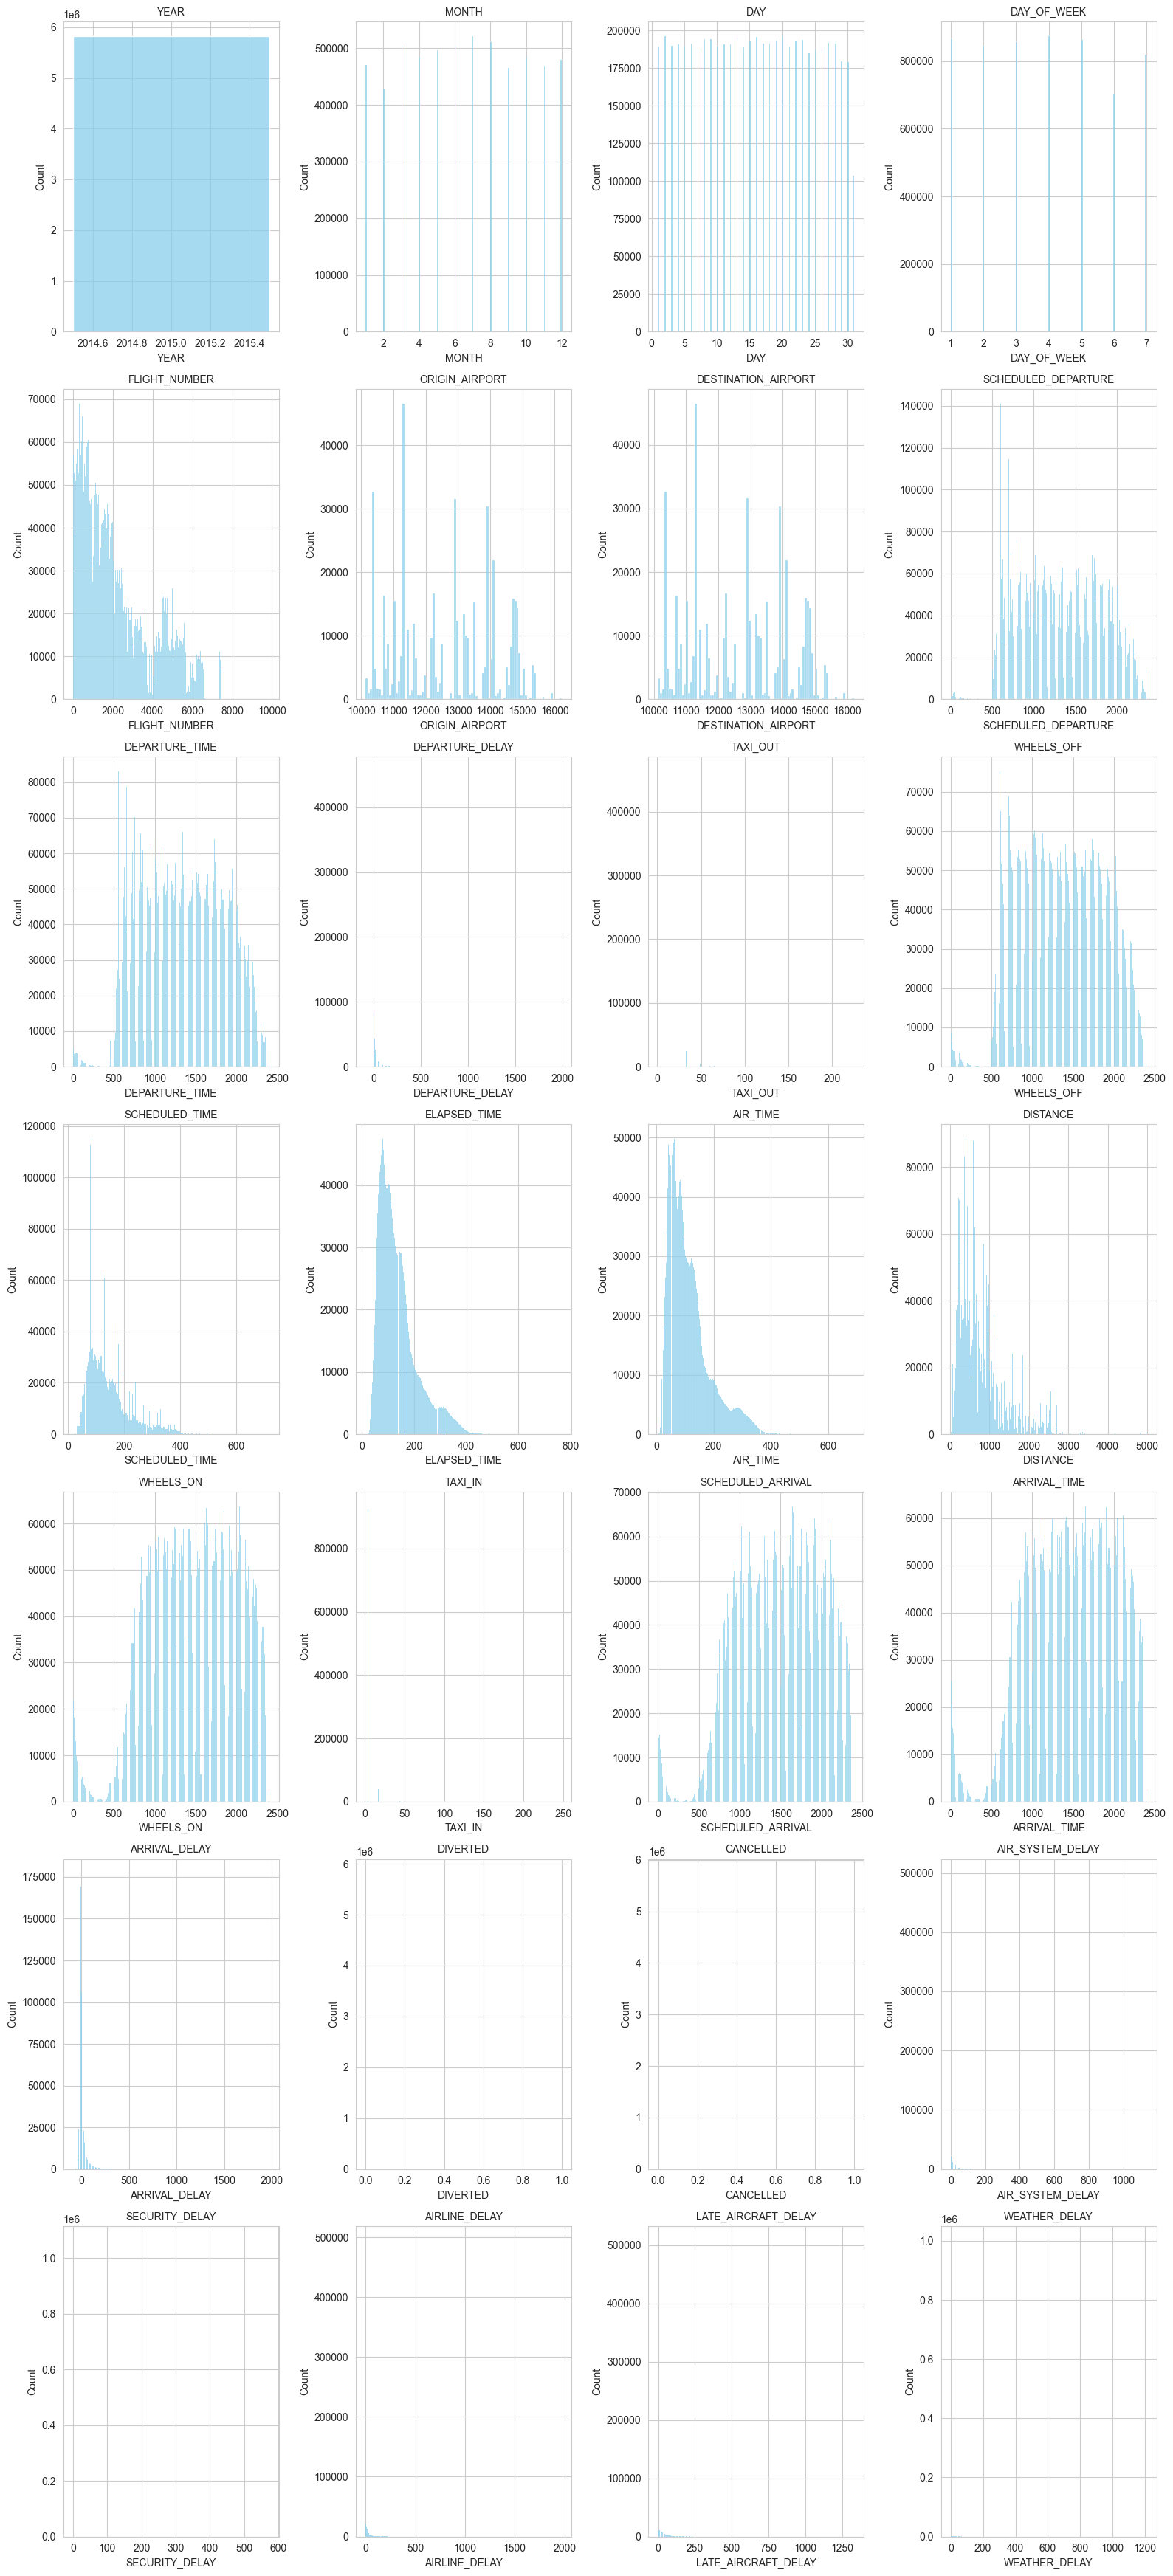

In [24]:



df = pd.read_csv("flights.csv", low_memory=False)
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna(axis=1, how='all')
df = df.dropna(thresh=5)

numeric_cols = df.select_dtypes(include=['number']).columns

number_of_columns = 4
number_of_plots = len(numeric_cols)
number_of_rows = math.ceil(number_of_plots / number_of_columns)

plt.figure(figsize=(2 * number_of_columns * 2, 5 * number_of_rows))

for i in range(number_of_plots):
    print(f"Plotting: {numeric_cols[i]}")
    plt.subplot(number_of_rows, number_of_columns, i + 1)
    sns.histplot(df[numeric_cols[i]], color='skyblue') 
    plt.title(numeric_cols[i], fontsize=10)

plt.tight_layout()
plt.show()

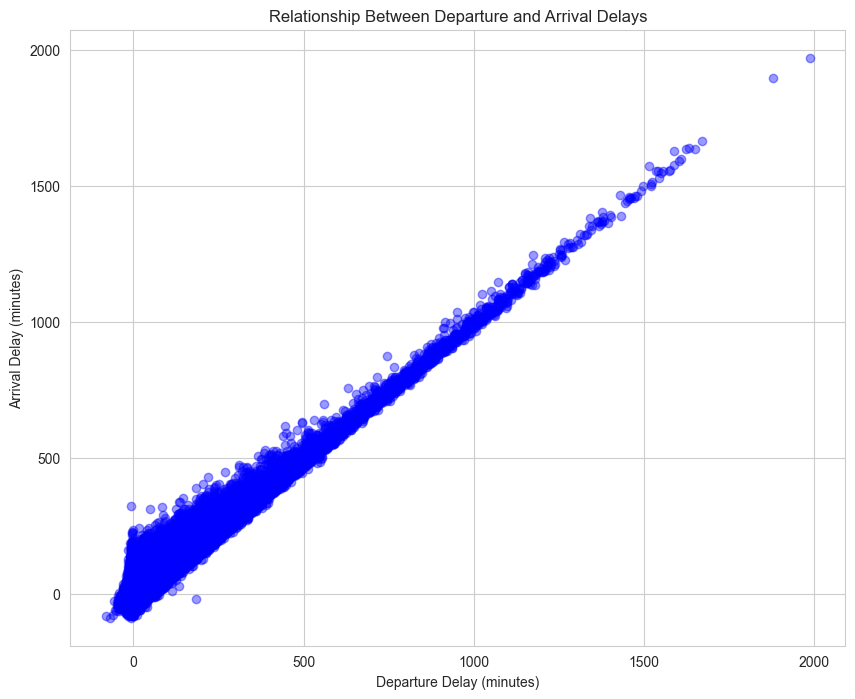

In [25]:


df = pd.read_csv("flights.csv", low_memory=False)

# Convert everything to numbers (non-numeric values become NaN)
df = df.apply(pd.to_numeric, errors='coerce')

# Drop rows where either value is missing
df = df.dropna(subset=['DEPARTURE_DELAY', 'ARRIVAL_DELAY'])

# Create the scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(df['DEPARTURE_DELAY'], df['ARRIVAL_DELAY'], alpha=0.4, color='blue', marker='o')

# Add labels
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("Arrival Delay (minutes)")
plt.title("Relationship Between Departure and Arrival Delays")

plt.grid(True)
plt.show()